# Homework Assignment



> Oskar Krawczyk, AIML22 Group 3







---

In this homework assignment, we will focus on the topics covered during the week 3 of Lady Margaret Hall Summer Programme. This time, we will explore the field of self-supervised learning for computer vision, with an emphasis on CLIP models which will be compared with similar architectures, including DINO and DINOv2.

For the practical part of this task, we will work with [TinyImageNet](https://cs231n.stanford.edu/reports/2017/pdfs/930.pdf) dataset, which is a scaled-down version of the ImageNet dataset. Using this, we will evaluate CLIP's zero-shot classification performance. This will involve specific text prompts for each image class based on the dataset's words file and their text embeddings. We will then perform classification using similarily matching between the text and image embeddings, followed by evaluation and metrics analysis. Finally, we will implement the main task - Image Search Engine. We will build functionalities to search for relevant visual data using both text-to-image and image-to-image queries.


In the following notebook, I split my solution into six separate sections - Part 1, 2, 3, 4, 5, 6 - which follow the convention used in the initial [ImageSearch_Clip.ipynb](https://www.dropbox.com/scl/fi/5tchk22pf8zatb1on5fnf/Image_Search_with_CLIP.ipynb?rlkey=9jzl0on4chjdtnb8xlckmy2s2&st=hbfegt3d&e=1&dl=0) notebook. Each section includes the code as part of my solution as well as a brief explanation of certain concepts not mentioned during lectures/seminars. At the end of this notebook, I also denote resources used to complete and/or improve the final results and additional steps I have taken (beyond the required ones) to complete the notebook.


---



## Part 1

In this section we first import all necessary libraries into a single cell. The reason is that in the future if someone tries to access the very same code, it is preferable to keep it in the single cell instead of having imports scattered across the entire notebook. Then, we set up the notebook by specifying settings for plotting (matplotlib/seaborn), device and verify versions of libraries imported. Finally, we download the dataset to later explore its structure and content.

It is recommended you run the following cell since depending on the environment and settings, some packages might not be included in the standard setup (especially, tinyimagenet and transformers libraries). While debugging, removing -qq might be beneficial since this flag displays critical errors only.

In [1]:
!pip -qq install tinyimagenet transformers

#### Library imports

In [2]:
import os
import tqdm
import random
import tqdm
import textwrap

import numpy as np
import pandas as pd

import torch
import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import seaborn as sns

from tinyimagenet import TinyImageNet
from transformers import CLIPModel, CLIPProcessor

from torch.utils.data import DataLoader

#### Notebook setup

Here, we configure the default settings for the notebook. First, we set the random seed to ensure the reproducibility of the results. Then, based on my preferences, we configure the default settings for matplotlib and seaborn packages to ensure consistent plotting. Finally, we display information regarding the imported libraries - if any methods change in the future versions of these packages, this is a reference point.

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

plt.rcParams["figure.figsize"] = (8, 8)
sns.set_style("darkgrid")

print("---- Notebook setup info ----")
print(f"Device:         {device}")
print(f"PyTorch:        {torch.__version__}")
print(f"Torchvision:    {torchvision.__version__}")
print(f"Numpy:          {np.__version__}")
print(f"Pandas:         {pd.__version__}")

---- Notebook setup info ----
Device:         cpu
PyTorch:        2.11.0+cpu
Torchvision:    0.26.0+cpu
Numpy:          2.0.2
Pandas:         2.2.2


#### Explore the dataset

Now, we first download the TinyImageNet dataset, specifically using the validation split. Then, we first examine the sturcture of the dataset - its statistics, applied transformations and number of samples. Finally, we visualise five random samples with their corresponding labels.

In [4]:
dataset = TinyImageNet("tiny-imagenet", split = "val")

100%|██████████| 248M/248M [00:15<00:00, 15.7MB/s]


In [5]:
print("--------- Dataset information ---------\n")

print(f"Dataset root path: {dataset.root}\n")

print(f"Transformations: {dataset.transform}\n")

print(f"Statistics")
print(f"- Mean: {dataset.mean}")
print(f"- Std:  {dataset.std}\n")

print(f"Number of samples: {len(dataset)}\n")
print(f"Number of classes: {len(dataset.classes)}")

--------- Dataset information ---------

Dataset root path: tiny-imagenet/tiny-imagenet-200/val

Transformations: ToTensor()

Statistics
- Mean: [0.485, 0.456, 0.406]
- Std:  [0.229, 0.224, 0.225]

Number of samples: 10000

Number of classes: 200


As we can see, when loading TinyImageNet we only perform a standard transformation to a tensor and use exactly the same normalisation statistics as the original ImageNet. Furthermore, as the name "Tiny" suggests, the dataset is much smaller - it contains only 200 classes compared to ImageNet's 1000, the number of samples is reduced to 10000 with images of smaller resolution - 64x64.

Before me move on to visualising the samples, we will take a closer look at a single image from our dataset. First of all, we will make sure that its size is indeed 64x64, but I would especially like to draw attention to the label that can be assigned to a single image and what data type it is. This will be helpful in further analysis of the dataset, visualising the samples and eventually evaluating the model itself.

In [6]:
single_sample = dataset[150]

print(f"--------- Sample image information ---------\n")
print(f"Image shape:        {list(single_sample[0].shape)}")
print(f"Class index:        {single_sample[1]}")
print(f"Class name(s):      {dataset.idx_to_words[single_sample[1]]}")

--------- Sample image information ---------

Image shape:        [3, 64, 64]
Class index:        3
Class name(s):      ['tailed frog', ' bell toad', ' ribbed toad', ' tailed toad', ' Ascaphus trui']


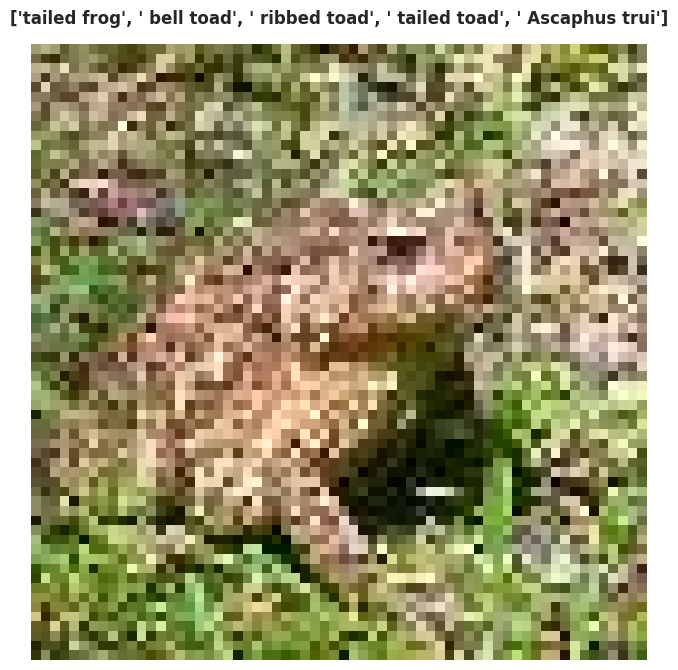

In [7]:
image, label = single_sample

plt.imshow(image.permute(1, 2, 0))
plt.title(f"{dataset.idx_to_words[label]}", fontweight = "bold", pad = 15)
plt.axis("off")
plt.show()

As we can see, labels of the images in our dataset are of list type, in particular an image can have various labels assigned. On how to deal with it during evaluation, we will elaborate further in the upcoming sections, but for now in the visualisation below we will assume that the first element in the list will be our label (otherwise visualisation might be distorted).

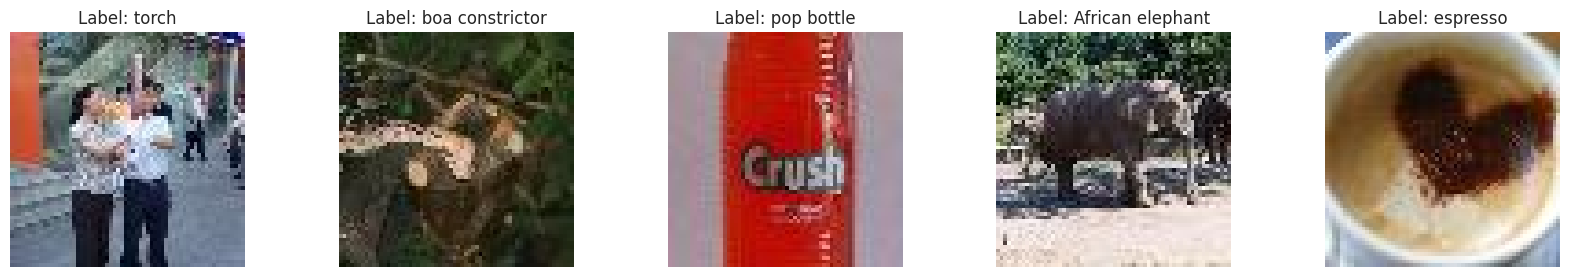

In [8]:
NUM_SAMPLES = 5

random_indicies = [random.randint(0, len(dataset) - 1) for _ in range(NUM_SAMPLES)]

fig, axes = plt.subplots(nrows = 1, ncols = NUM_SAMPLES, figsize = (20, 4))
plt.subplots_adjust(wspace = .4)

for i in range(NUM_SAMPLES):
    image, label = dataset[random_indicies[i]]

    named_label = dataset.idx_to_words[label][0]
    label_str = str(named_label)
    wrapped_label = "\n".join(textwrap.wrap(label_str, width = 25))

    axes[i].imshow(image.permute(1, 2, 0).cpu())
    axes[i].set_title(f"Label: {wrapped_label}")
    axes[i].axis("off")

## Part 2

In this section we will load the base model and preprocessor that we will be using throughout this notebook, namely [CLIP-ViT-base-patch32](https://huggingface.co/openai/clip-vit-base-patch32). Since the main building blocks of the CLIP architecture were covered in the lectures, we will only briefly discuss what characterises this architecture in particular. As the name suggests:



*   ViT - rather than a traditional convolutional neural network like ResNet, it uses Vision Transformer as its image encoder.
*   Patch 32 - before the image is fed into the ViT, it is divided into a grid of 32x32 pixels squares.


![CLIP Architecture](https://github.com/openai/CLIP/raw/main/CLIP.png)

For more details check [Learning Transferable Visual Models From Natural Language Supervision](https://arxiv.org/pdf/2103.00020) paper.

In [9]:
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  605MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

...

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

In [10]:
model.to(device)

CLIPModel(
  (text_model): CLIPTextModel(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e-05, eleme

## Part 3